# Bitcoin Data and Exploratory Analysis

## Role
Canonical UTC data preparation and split definition.

## Inputs
`data/bitcoin/btcusd_1-min_data.csv`

## Outputs
Executed dataset, missingness, aggregation, return, volatility, and split summaries.

## Depends On
Raw Bitcoin source data.

## Authoritative Status
AUTHORITATIVE DATA PREPARATION

## What This Notebook Does Not Do
It does not train models or write forecast artifacts.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.bitcoin_pipeline import *
RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False


In [2]:
# Load the canonical target and chronological split.
daily, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)

# Load the minute-level source for the audit summary.
raw = load_bitcoin_data(ROOT / 'data' / 'bitcoin' / 'btcusd_1-min_data.csv')
summary = pd.DataFrame({
    'Value': [
        len(raw),
        raw.Timestamp.min(),
        raw.Timestamp.max(),
        len(daily),
        int(daily.isna().sum().sum()),
        target.index.min(),
        target.index.max(),
    ]
}, index=[
    'Minute rows', 'Minute start', 'Minute end', 'UTC daily rows',
    'Daily missing values', 'Target start', 'Target end',
])

# Display the unchanged data audit.
summary

,Value
Minute rows,7633557
Minute start,2012-01-01 00:01:00+00:00
Minute end,2026-07-07 01:57:00+00:00
UTC daily rows,5302
Daily missing values,0
Target start,2012-01-01 00:00:00+00:00
Target end,2026-07-07 00:00:00+00:00


## Daily aggregation
Open=first, High=max, Low=min, Close=last, Volume=sum in UTC calendar days. The target is the last available Close in each UTC date.

In [3]:
# Summarise the fixed chronological partitions.
pd.DataFrame({
    'Start': [train.index.min(), test.index.min()],
    'End': [train.index.max(), test.index.max()],
    'Rows': [len(train), len(test)],
}, index=['Train', 'Test'])

,Start,End,Rows
Train,2012-01-01 00:00:00+00:00,2023-08-11 00:00:00+00:00,4241
Test,2023-08-12 00:00:00+00:00,2026-07-07 00:00:00+00:00,1061


## Price history and fixed evaluation boundary

The logarithmic price axis keeps the full 2012–2026 history legible. The shaded region begins at the first held-out date; it is a visual annotation of the already-fixed chronological split, not a new split calculation.

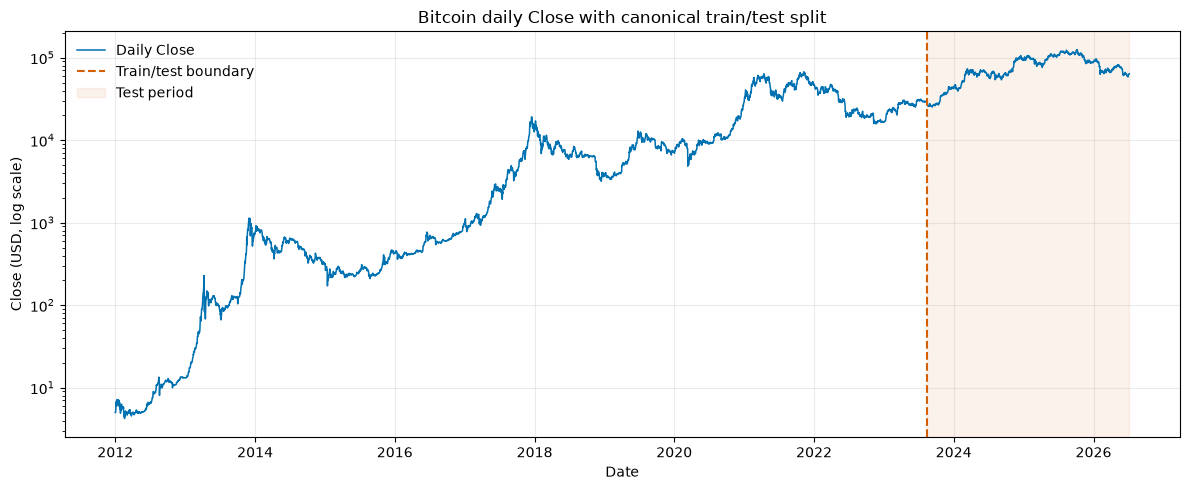

In [4]:
import matplotlib.pyplot as plt

# Plot the full target history and annotate the canonical split.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(target.index, target, color='#0072B2', linewidth=1.1, label='Daily Close')
ax.axvline(test.index.min(), color='#D55E00', linestyle='--', linewidth=1.5, label='Train/test boundary')
ax.axvspan(test.index.min(), target.index.max(), color='#D55E00', alpha=0.08, label='Test period')
ax.set_yscale('log')
ax.set(title='Bitcoin daily Close with canonical train/test split', xlabel='Date', ylabel='Close (USD, log scale)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [5]:
# Derive presentation-only return and volatility series.
eda = pd.DataFrame({
    'Close': target,
    'Log Return': np.log(target / target.shift(1)),
})
eda['30-Day Volatility'] = eda['Log Return'].rolling(30).std()

# Display the unchanged diagnostic tail.
eda.tail()

,Close,Log Return,30-Day Volatility
Timestamp,,,
2026-07-03 00:00:00+00:00,62522.46,0.016829,0.019967
2026-07-04 00:00:00+00:00,63086.18,0.008976,0.020038
2026-07-05 00:00:00+00:00,63587.06,0.007908,0.018272
2026-07-06 00:00:00+00:00,64000.10,0.006475,0.018276
2026-07-07 00:00:00+00:00,63902.77,-0.001522,0.016819


## Returns and rolling volatility

Daily log returns remove the changing price scale, while the rolling standard deviation makes volatility clustering visible without changing any downstream regime definition.

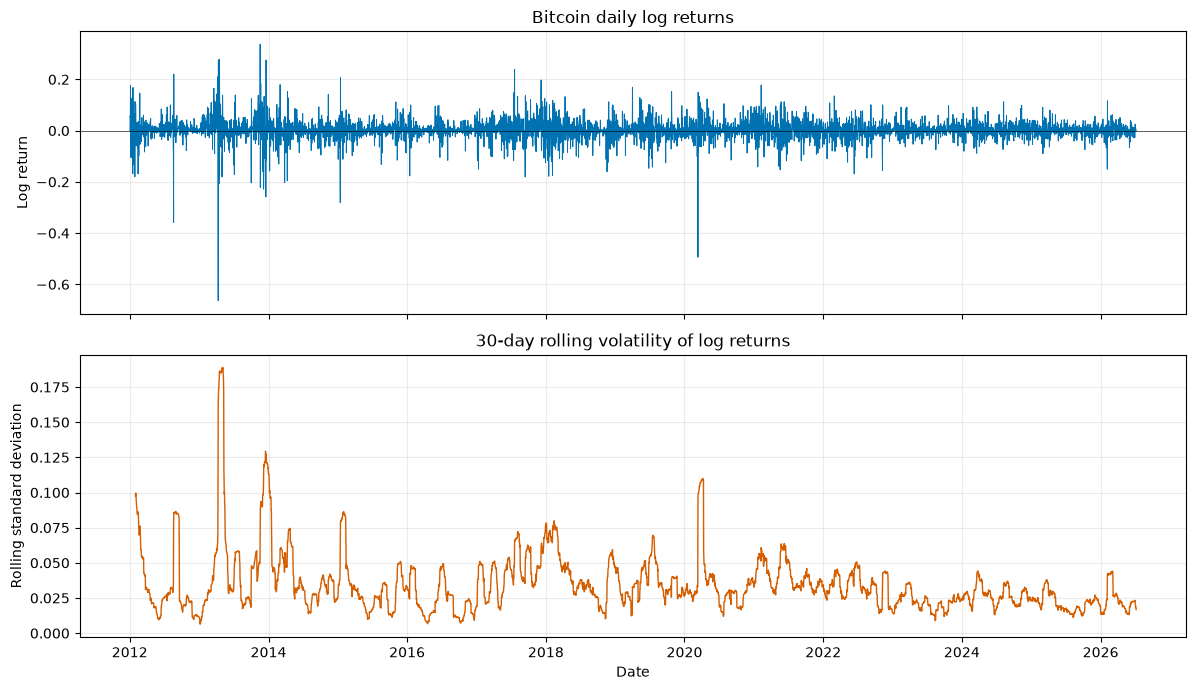

In [6]:
# Plot daily log returns and their 30-day rolling volatility.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(eda.index, eda['Log Return'], color='#0072B2', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.7, alpha=0.6)
axes[0].set(title='Bitcoin daily log returns', ylabel='Log return')
axes[1].plot(eda.index, eda['30-Day Volatility'], color='#D55E00', linewidth=1.0)
axes[1].set(title='30-day rolling volatility of log returns', xlabel='Date', ylabel='Rolling standard deviation')
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Returns distribution

The normal curve is a visual reference fitted to the observed log-return mean and standard deviation; it is not a distributional assumption used by the forecasting pipeline.

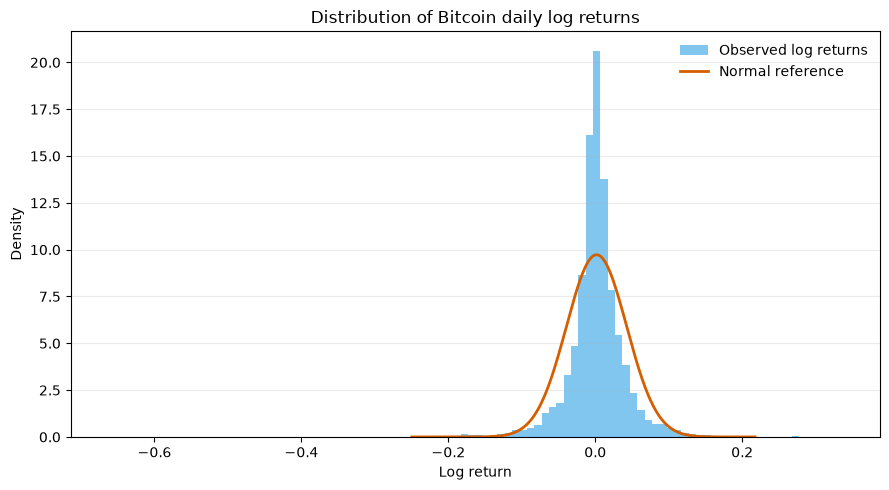

In [7]:
from scipy import stats

# Prepare finite daily log returns and a same-moment normal reference.
returns = eda['Log Return'].dropna()
x = np.linspace(returns.quantile(0.001), returns.quantile(0.999), 500)
normal_density = stats.norm.pdf(x, loc=returns.mean(), scale=returns.std(ddof=1))

# Compare the empirical distribution with the fitted normal density.
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(returns, bins=100, density=True, color='#56B4E9', alpha=0.75, label='Observed log returns')
ax.plot(x, normal_density, color='#D55E00', linewidth=2, label='Normal reference')
ax.set(title='Distribution of Bitcoin daily log returns', xlabel='Log return', ylabel='Density')
ax.grid(axis='y', alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Key Findings

The raw daily price is strongly non-stationary across the displayed history, while day-to-day changes are small relative to the price level, making one-step persistence an essential benchmark for near-random-walk behaviour. Log returns vary around zero but show clustered periods of elevated 30-day volatility, directly motivating the later training-defined regime-conditional robustness checks. The return histogram also departs visibly from its same-moment normal reference, so the evaluation does not rely on a Gaussian-return interpretation.

## Limitation
The final UTC date contains only the available observations through 01:57 UTC and therefore represents a partial daily observation rather than a completed 24-hour UTC trading day.